# EDA por equipo — ¿importa para quién juega el receptor?

## Qué preguntas responde este notebook

Ninguno de los análisis anteriores (ni los de `preeliminar`, verificado antes de empezar) mira al
equipo como unidad de análisis — solo se usa como llave para unir tablas. Aquí se pregunta
directamente:

1. **¿Qué equipos producen más yardas desde la posición WR, en conjunto?**
2. **¿Qué defensas son más duras contra los receptores?**
3. **¿Esto se mantiene de una temporada a otra, o cambia tanto que no serviría como feature?**

La tercera pregunta es la que más importa para el proyecto: en la Fase 2 se pospuso construir
features de equipo (ofensiva/defensiva) hasta tener evidencia de que valen la pena — este
notebook es esa evidencia.

In [1]:
import sys
sys.path.insert(0, "../src")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import data

sns.set_style("whitegrid")
AZUL, NARANJA, VERDE, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#1baf7a", "#888780", "#c3c2b7"

SEASONS = [2024, 2025]
stats = data.cargar_stats_semanales(SEASONS)
wr = stats[(stats["position"] == "WR") & (stats["targets"] > 0)].copy()
print("filas WR activas:", wr.shape[0], "| equipos:", wr['team'].nunique())

filas WR activas: 4187 | equipos: 32


## 1. ¿Qué equipos producen más desde la posición WR?

Se suman las yardas de recepción de WR de cada equipo por semana (todos los receptores juntos,
no uno solo), y se promedia esa suma a lo largo de la temporada 2024.

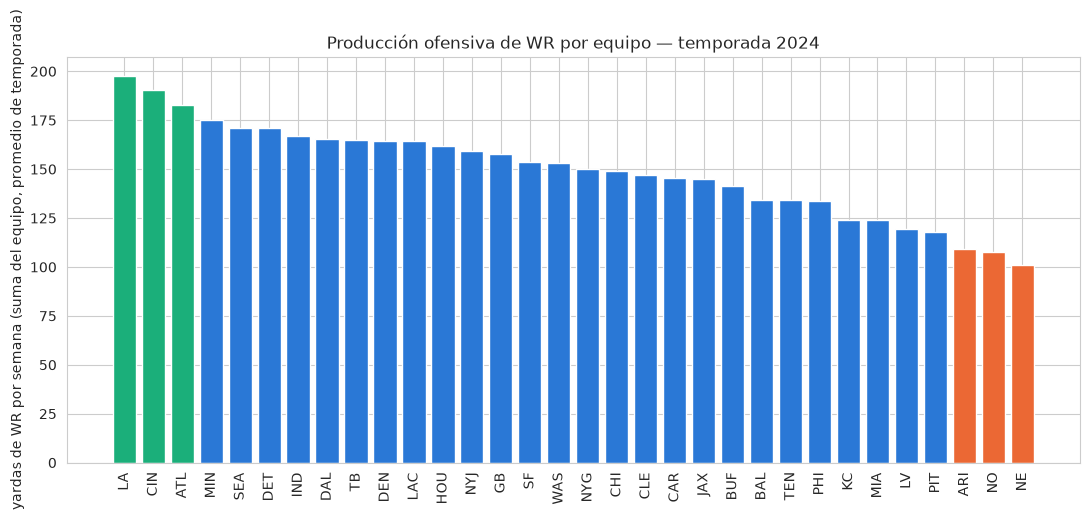

top 3: {'LA': 197.47058823529412, 'CIN': 190.23529411764707, 'ATL': 183.0}
bottom 3: {'ARI': 109.3529411764706, 'NO': 107.82352941176471, 'NE': 101.05882352941177}
rango (mejor - peor): 96.4 yardas/semana


In [2]:
of_semana = wr.groupby(["season", "team", "week"])["receiving_yards"].sum().reset_index()
of_2024 = (
    of_semana[of_semana["season"] == 2024]
    .groupby("team")["receiving_yards"].mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 5))
colores = [VERDE if i < 3 else (NARANJA if i >= len(of_2024) - 3 else AZUL) for i in range(len(of_2024))]
ax.bar(of_2024.index, of_2024.values, color=colores)
ax.set_ylabel("yardas de WR por semana (suma del equipo, promedio de temporada)")
ax.set_title("Producción ofensiva de WR por equipo — temporada 2024")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("top 3:", of_2024.head(3).to_dict())
print("bottom 3:", of_2024.tail(3).to_dict())
print("rango (mejor - peor):", round(of_2024.max() - of_2024.min(), 1), "yardas/semana")

Hay una diferencia real y grande entre el mejor y el peor equipo — no es ruido. Los Rams (LA) y
los Bengals (CIN) producen casi el doble por semana desde WR que Nueva Inglaterra (NE) o New
Orleans (NO).

## 2. ¿Qué defensas son más duras contra los receptores?

Mismo cálculo, pero agrupando por `opponent_team` — cuántas yardas de WR permitió cada equipo
cuando jugó de rival, no cuánto produjo su propia ofensiva.

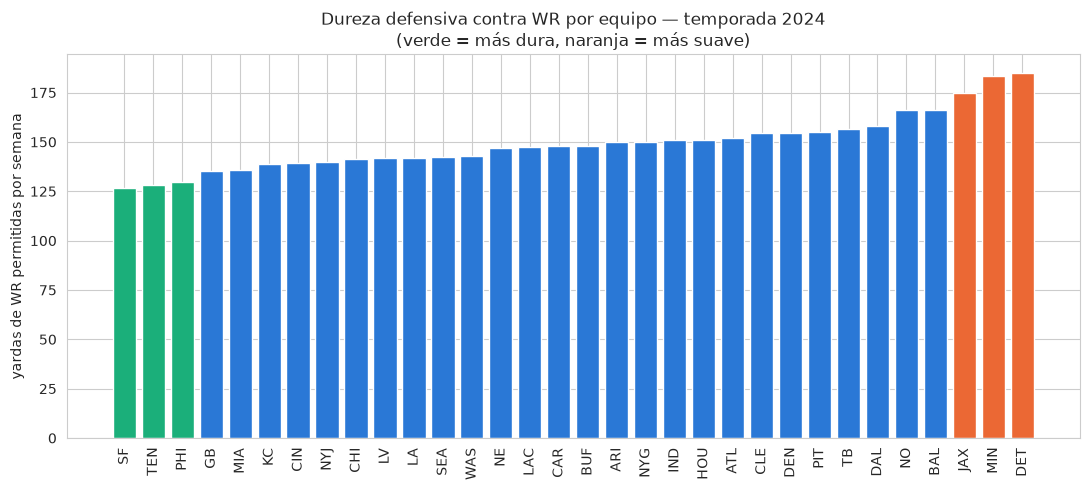

defensas mas duras: {'SF': 126.88235294117646, 'TEN': 128.05882352941177, 'PHI': 129.52941176470588}
defensas mas suaves: {'JAX': 174.8235294117647, 'MIN': 183.23529411764707, 'DET': 185.11764705882354}
rango: 58.2 yardas/semana


In [3]:
def_semana = wr.groupby(["season", "opponent_team", "week"])["receiving_yards"].sum().reset_index()
def_2024 = (
    def_semana[def_semana["season"] == 2024]
    .groupby("opponent_team")["receiving_yards"].mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(11, 5))
colores = [VERDE if i < 3 else (NARANJA if i >= len(def_2024) - 3 else AZUL) for i in range(len(def_2024))]
ax.bar(def_2024.index, def_2024.values, color=colores)
ax.set_ylabel("yardas de WR permitidas por semana")
ax.set_title("Dureza defensiva contra WR por equipo — temporada 2024\n(verde = más dura, naranja = más suave)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("defensas mas duras:", def_2024.head(3).to_dict())
print("defensas mas suaves:", def_2024.tail(3).to_dict())
print("rango:", round(def_2024.max() - def_2024.min(), 1), "yardas/semana")

También hay una diferencia real (58 yardas/semana entre la más dura y la más suave) — pero antes
de convertir esto en feature, falta la pregunta más importante: **¿esto se repite el año
siguiente, o es propio de una sola temporada?**

## 3. ¿Es esto estable de 2024 a 2025?

Se repite el mismo cálculo para 2025 y se compara equipo por equipo.

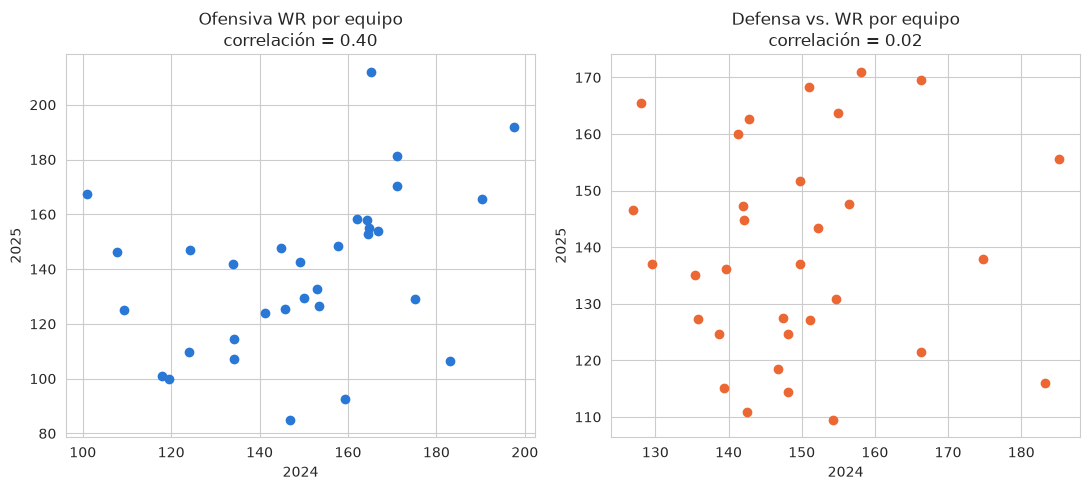

correlacion ofensiva WR 2024 vs 2025: 0.397
correlacion defensa vs WR 2024 vs 2025: 0.019


In [4]:
of_2025 = (
    of_semana[of_semana["season"] == 2025]
    .groupby("team")["receiving_yards"].mean()
)
def_2025 = (
    def_semana[def_semana["season"] == 2025]
    .groupby("opponent_team")["receiving_yards"].mean()
)

comp_of = of_2024.to_frame("2024").join(of_2025.to_frame("2025"), how="inner")
comp_def = def_2024.to_frame("2024").join(def_2025.to_frame("2025"), how="inner")

corr_of = comp_of["2024"].corr(comp_of["2025"])
corr_def = comp_def["2024"].corr(comp_def["2025"])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].scatter(comp_of["2024"], comp_of["2025"], color=AZUL)
axes[0].set_xlabel("2024"); axes[0].set_ylabel("2025")
axes[0].set_title(f"Ofensiva WR por equipo\ncorrelación = {corr_of:.2f}")

axes[1].scatter(comp_def["2024"], comp_def["2025"], color=NARANJA)
axes[1].set_xlabel("2024"); axes[1].set_ylabel("2025")
axes[1].set_title(f"Defensa vs. WR por equipo\ncorrelación = {corr_def:.2f}")

plt.tight_layout()
plt.show()

print(f"correlacion ofensiva WR 2024 vs 2025: {corr_of:.3f}")
print(f"correlacion defensa vs WR 2024 vs 2025: {corr_def:.3f}")

**Este es el hallazgo central del notebook, y tiene una implicación directa y distinta para cada
lado:**

- **Ofensiva (0.40 de correlación)**: hay continuidad real, aunque no perfecta. Un equipo que
  produce mucho desde WR un año tiende a seguir produciendo por encima del promedio al año
  siguiente — tiene sentido, porque buena parte de la misma plantilla de receptores y el mismo
  esquema ofensivo se mantienen. **Vale la pena probar un feature de "calidad ofensiva del
  equipo" en Fase 4.**
- **Defensa (0.02, prácticamente cero)**: una defensa dura contra WR un año no predice nada sobre
  el año siguiente. Esto tiene una explicación real, no es ruido de la medición: las defensas
  cambian de jugadores clave, de esquema, y de coordinador con mucha más frecuencia que las
  unidades ofensivas de receptores — y encima, "dureza contra WR" depende mucho de a qué
  ofensivas rivales le tocó enfrentar ese año en particular. **Un feature de "dureza histórica de
  la defensa rival", calculado con la temporada anterior, probablemente no aportaría nada — si se
  construye algo de dificultad de rival, tendría que ser dentro de la misma temporada en curso
  (acumulado semana a semana), no heredado del año pasado.**

**Aclaración importante para no leer esto como contradictorio con otro notebook**:
[`08_eda_multivariable.ipynb`](08_eda_multivariable.ipynb) calcula algo parecido pero no es lo
mismo — ahí se mide si la ofensiva del equipo *dentro de la misma temporada* (acumulada semana a
semana) correlaciona con el rendimiento de **un jugador individual**, y da un número mucho más
modesto (~0.08). Eso no contradice el 0.40 de aquí: una cosa es "¿la calidad ofensiva de un
equipo se mantiene de un año a otro?" (sí, con evidencia real — este notebook) y otra distinta es
"¿esa calidad de equipo por sí sola predice bien a un jugador específico?" (poco — el `target_share`
propio del jugador sigue siendo mucho más fuerte). Las dos cosas son ciertas a la vez: el
equipo importa, pero menos que el rol del jugador dentro de ese equipo. La dureza defensiva, en
cambio, sí es consistente entre ambos notebooks — cercana a cero en los dos.

## Cierre

- Sí importa para qué equipo juega un receptor — hay diferencias reales y grandes entre equipos,
  tanto en ofensiva propia como en la defensa que enfrenta.
- Pero la ofensiva del equipo es mucho más estable año con año (0.40) que la defensa rival contra
  WR (0.02, casi aleatoria) — evidencia concreta y directa para la Fase 4: un feature de
  "ofensiva del equipo" tiene una base razonable para probarse; un feature de "dureza histórica
  de la defensa rival" basado en la temporada anterior, no.
- Esto no estaba explorado en ningún notebook previo (ni en `preeliminar`) — es terreno
  genuinamente nuevo para el proyecto.

Notebook anterior: [`06_eda_general.ipynb`](06_eda_general.ipynb) · Siguiente: [`08_eda_multivariable.ipynb`](08_eda_multivariable.ipynb)